# Phase 8 — Hybride texte + tabulaire

**Question testée** : ajouter les embeddings sentence-transformers des verbatims (384 dims) au tabulaire (~94 dims) fait-il bouger le QWK silent ?

**Champion à battre** (Phase 7) : `tuned/logistic` avec **QWK silent = 0.355** (Detractor recall = 0.840).

**Plan** :
1. Charger `dataset_with_verbatims` + splits response_biased + pipeline tabulaire fitté.
2. Calculer/charger embeddings `all-MiniLM-L6-v2` (384 dims, cache content-hash).
3. Construire 2 espaces de features : **concat** brut (478 dims) et **pca32** (126 dims, PCA fittée train-only).
4. Tuner en parallèle 2 modèles × 2 espaces = **4 études Optuna** (LGBM × {concat, pca32}, Logistic × {concat, pca32}).
5. Comparer baseline (Phase 6) → tuned tab-only (Phase 7) → hybrid (Phase 8) sur silent_test.
6. Identifier le nouveau champion + diagnostics + synthèse honnête.

**Honesty bar** (préalablement engagée) : si `Δ QWK silent < 0.02` entre tab-only champion et hybrid champion, le rapport conclut que le texte n'apporte pas de valeur pour ce dataset.

## 1. Setup

In [1]:
# Repo root on path
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print(f"Working dir: {ROOT}")

Working dir: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction


In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, FIGURES_DIR,
    DEFAULT_TARGET, RANDOM_SEED, TUNING_BUDGETS,
)
from src.data.split import load_splits

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print(f"Target: {DEFAULT_TARGET}")
print(f"Tuning budgets (Phase 7 reused): {TUNING_BUDGETS}")

Target: NPS_alternative
Tuning budgets (Phase 7 reused): {'lightgbm': 50, 'logistic': 30, 'ordinal': 20}


## 2. Charger dataset enrichi de verbatims + splits

In [3]:
df = pd.read_parquet(DATA_PROCESSED / "dataset_with_verbatims.parquet")
splits = load_splits("response_biased")
pipeline = joblib.load(MODELS_DIR / "preprocessing_pipeline.joblib")

print(f"Dataset: {df.shape}")
print(f"  has 'verbatim' column: {'verbatim' in df.columns}")
print(f"  null verbatims: {df['verbatim'].isna().sum() if 'verbatim' in df.columns else 'N/A'}")
print(f"\nSplits:")
print(splits.value_counts().to_string())

Dataset: (7043, 56)
  has 'verbatim' column: True
  null verbatims: 0

Splits:
split
silent_test        5987
train               634
val                 211
respondent_test     211


## 3. Calculer (ou charger depuis cache) les embeddings

Premier run : ~30-60 sec sur CPU pour 7 043 verbatims (model `all-MiniLM-L6-v2`, 384 dims).
Runs suivants : <1 sec (cache content-hash sur `data/processed/verbatim_embeddings.parquet`).

In [4]:
from src.features.embeddings import (
    load_or_compute_embeddings,
    DEFAULT_EMBEDDING_MODEL,
    DEFAULT_EMBEDDING_DIM,
)

emb_df = load_or_compute_embeddings(df, model_name=DEFAULT_EMBEDDING_MODEL, verbose=True)
print(f"\nEmbeddings: {emb_df.shape}  (mem={emb_df.memory_usage(deep=True).sum()/1e6:.1f} MB)")
print(f"Index aligned with df: {emb_df.index.equals(df.index)}")
emb_df.head(3).iloc[:, :6]

  ✓ Using cached embeddings: verbatim_embeddings.parquet

Embeddings: (7043, 384)  (mem=11.3 MB)
Index aligned with df: True


,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005
Customer ID,,,,,,
3668-QPYBK,-0.006602,-0.053381,0.023383,0.015621,0.022340,-0.041404
9237-HQITU,-0.005781,-0.010816,0.101852,0.006053,0.010539,-0.057854
9305-CDSKC,0.005567,0.052809,0.090953,0.031166,0.037177,-0.036248


## 4. Construire les 2 espaces hybrides

Pour la PCA, **on fit uniquement sur le train** (sinon leakage train→test).

| Espace | Tabulaire | Embeddings | Total | Justification |
|---|---|---|---|---|
| `concat` | ~94 | 384 brut | ~478 | Approche directe — laisse le modèle gérer la haute dim |
| `pca32` | ~94 | 32 (PCA train-only) | ~126 | Réduction prudente, ratio n/p sain |

In [5]:
from sklearn.decomposition import PCA
from src.models.tuning_hybrid import VERBATIM_AUX_COLS

feature_cols = [c for c in df.columns
                if not c.startswith("NPS_") and c not in VERBATIM_AUX_COLS]

# Tabulaire encodé sur train pour illustration
X_tab_train = pipeline.transform(df.loc[splits == "train", feature_cols])
X_emb_train = emb_df.loc[df.index[splits == "train"]].to_numpy()

# PCA fitté train uniquement
pca = PCA(n_components=32, random_state=RANDOM_SEED)
X_emb_pca_train = pca.fit_transform(X_emb_train)

print(f"Tabulaire encodé : {X_tab_train.shape[1]:>4} dims")
print(f"Embeddings concat : {X_emb_train.shape[1]:>4} dims")
print(f"Embeddings pca32  : {X_emb_pca_train.shape[1]:>4} dims  "
      f"(variance expliquée = {pca.explained_variance_ratio_.sum():.1%})")
print(f"\nHybrid concat : {X_tab_train.shape[1] + X_emb_train.shape[1]:>4} dims")
print(f"Hybrid pca32  : {X_tab_train.shape[1] + 32:>4} dims")
print(f"\nn_train = {(splits == 'train').sum()}")
print(f"  → ratio n/p concat = {(splits == 'train').sum() / (X_tab_train.shape[1] + X_emb_train.shape[1]):.2f}")
print(f"  → ratio n/p pca32  = {(splits == 'train').sum() / (X_tab_train.shape[1] + 32):.2f}")

Tabulaire encodé :   94 dims
Embeddings concat :  384 dims
Embeddings pca32  :   32 dims  (variance expliquée = 77.3%)

Hybrid concat :  478 dims
Hybrid pca32  :  126 dims

n_train = 634
  → ratio n/p concat = 1.33
  → ratio n/p pca32  = 5.03


## 5. Lancer le tuning hybride

**Coût attendu** : ~15 min CPU pour 4 × ~40 trials = ~160 trials Optuna.

Si déjà fait, on saute (les artifacts seront chargés en cellule 6).

> Si tu lances en notebook, décommente la cellule. Sinon, en CLI :
> ```bash
> make tune-hybrid    # ou : python -m src.models.tuning_hybrid
> ```

In [ ]:
# Décommente pour exécuter dans le notebook
# from src.models.tuning_hybrid import run_hybrid_tuning
# summary = run_hybrid_tuning(verbose=True)

print("Lance `make tune-hybrid` puis ré-exécute la suite du notebook.")

## 6. Charger résultats baseline (Phase 6) + tuned (Phase 7) + hybrid (Phase 8)

In [6]:
baseline_df = pd.read_parquet(RESULTS_DIR / "baseline_results.parquet")
tuned_df    = pd.read_parquet(RESULTS_DIR / "tuned_results.parquet")
hybrid_df   = pd.read_parquet(RESULTS_DIR / "hybrid_results.parquet")

# Ne garder que le mapping principal (NPS_alternative)
target = DEFAULT_TARGET
baseline_df = baseline_df[baseline_df["target"] == target].copy()
tuned_df    = tuned_df[tuned_df["target"] == target].copy()
hybrid_df   = hybrid_df[hybrid_df["target"] == target].copy()

# Harmoniser
baseline_df["phase"] = "baseline"
baseline_df["feature_space"] = "tabular"
tuned_df["feature_space"]    = "tabular"
# hybrid_df["phase"]/["feature_space"] déjà en place

cols = ["phase", "model", "feature_space", "split", "n",
        "qwk", "macro_f1", "balanced_acc", "detractor_recall",
        "lift@10", "lift@20",
        "recall_detractor", "recall_passive", "recall_promoter"]
cols = [c for c in cols if all(c in d.columns for d in [baseline_df, tuned_df, hybrid_df])]
combined = pd.concat([baseline_df[cols], tuned_df[cols], hybrid_df[cols]], ignore_index=True)

print(f"baseline: {len(baseline_df)} rows  |  tuned: {len(tuned_df)} rows  |  hybrid: {len(hybrid_df)} rows")
print(f"Combined: {combined.shape}")
combined.head()

baseline: 12 rows  |  tuned: 12 rows  |  hybrid: 16 rows
Combined: (40, 14)


,phase,model,feature_space,split,n,qwk,macro_f1,balanced_acc,detractor_recall,lift@10,lift@20,recall_detractor,recall_passive,recall_promoter
0,baseline,logistic,tabular,silent_test,5987,0.344484,0.482439,0.567629,0.747451,2.449923,2.236041,0.747451,0.393000,0.562436
1,baseline,logistic,tabular,val,211,0.250519,0.421216,0.507765,0.636364,2.435786,2.740260,0.636364,0.359155,0.527778
2,baseline,logistic,tabular,respondent_test,211,0.357382,0.525888,0.597240,0.676471,2.659664,2.364146,0.676471,0.531915,0.583333
3,baseline,logistic,tabular,train,634,0.549429,0.643285,0.757406,0.908163,4.620991,4.107548,0.908163,0.567757,0.796296
4,baseline,ordinal,tabular,silent_test,5987,0.225356,0.403052,0.403130,0.243922,2.442071,1.223938,0.243922,0.880844,0.084623


## 7. Convergence Optuna sur les 4 études hybrides

In [7]:
trials_h = pd.read_parquet(RESULTS_DIR / "hybrid_tuning_trials.parquet")
print(f"Total trials hybrides : {len(trials_h)}")
print(trials_h.groupby(['model', 'feature_space']).size().rename('n_trials'))

Total trials hybrides : 160
model     feature_space
lightgbm  concat           50
          pca32            50
logistic  concat           30
          pca32            30
Name: n_trials, dtype: int64


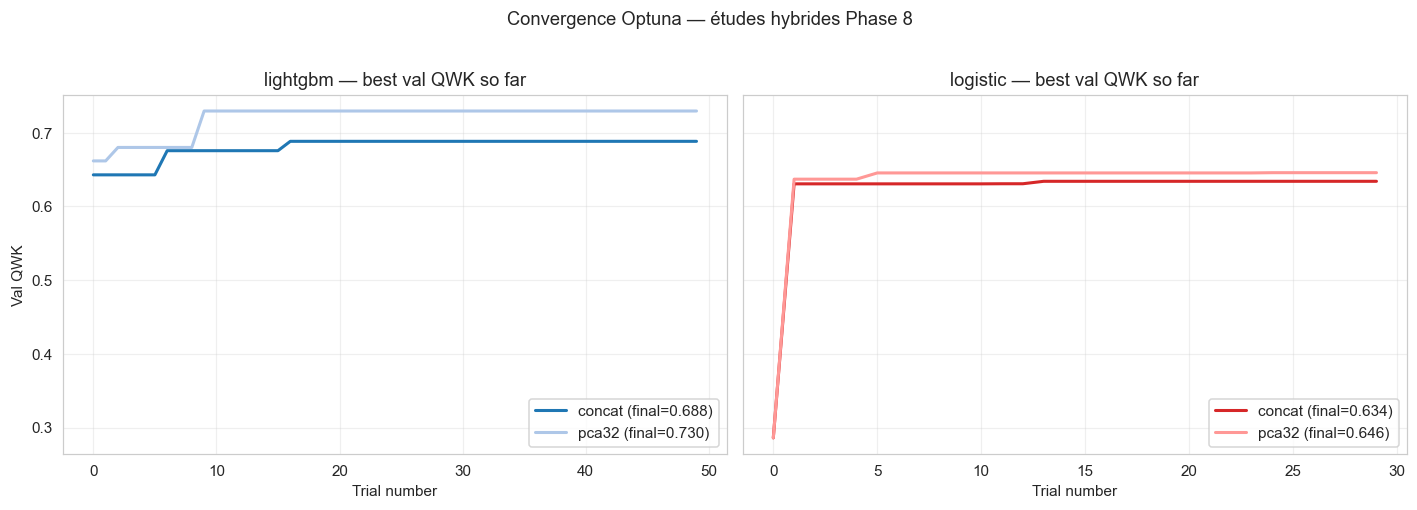

✓ saved reports/figures/33_optuna_convergence_hybrid.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

palette = {
    ("lightgbm", "concat"): "#1f77b4",
    ("lightgbm", "pca32"):  "#aec7e8",
    ("logistic", "concat"): "#d62728",
    ("logistic", "pca32"):  "#ff9896",
}

for ax, model in zip(axes, ["lightgbm", "logistic"]):
    for fs in ["concat", "pca32"]:
        sub = trials_h[(trials_h["model"] == model) & (trials_h["feature_space"] == fs)]
        sub = sub.sort_values("number")
        if len(sub) == 0:
            continue
        best_so_far = sub["value"].cummax()
        ax.plot(sub["number"], best_so_far,
                label=f"{fs} (final={best_so_far.iloc[-1]:.3f})",
                color=palette[(model, fs)], linewidth=2)
    ax.set_xlabel("Trial number")
    ax.set_title(f"{model} — best val QWK so far")
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Val QWK")
plt.suptitle("Convergence Optuna — études hybrides Phase 8", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "33_optuna_convergence_hybrid.png",
            dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ saved reports/figures/33_optuna_convergence_hybrid.png")

## 8. Comparaison directe baseline → tuned → hybrid sur silent_test

In [9]:
silent = combined[combined["split"] == "silent_test"].copy()
silent["candidate"] = silent["phase"] + " / " + silent["model"] + " / " + silent["feature_space"]

cols_show = ["candidate", "qwk", "macro_f1", "detractor_recall", "lift@10"]
cols_show = [c for c in cols_show if c in silent.columns]
print("\nSilent_test — tous les candidats :\n")
print(silent[cols_show].sort_values("qwk", ascending=False).to_string(index=False))


Silent_test — tous les candidats :

                    candidate      qwk  macro_f1  detractor_recall  lift@10
    hybrid / lightgbm / pca32 0.659483  0.738985          0.636078 2.850392
   hybrid / logistic / concat 0.630034  0.712883          0.803137 2.913210
   hybrid / lightgbm / concat 0.627684  0.708901          0.825098 2.811130
    hybrid / logistic / pca32 0.616466  0.711238          0.730980 2.724754
   tuned / logistic / tabular 0.354653  0.482489          0.840000 2.756164
baseline / logistic / tabular 0.344484  0.482439          0.747451 2.449923
   tuned / lightgbm / tabular 0.324191  0.459922          0.843137 2.552003
baseline / lightgbm / tabular 0.308216  0.492328          0.648627 2.591265
    tuned / ordinal / tabular 0.228879  0.406336          0.258039 2.418514
 baseline / ordinal / tabular 0.225356  0.403052          0.243922 2.442071


In [10]:
# Δ vs champion Phase 7 (tab-only tuned/logistic)
phase7_champion = silent[
    (silent["phase"] == "tuned")
    & (silent["model"] == "logistic")
    & (silent["feature_space"] == "tabular")
]
champ7_qwk = float(phase7_champion["qwk"].iloc[0]) if len(phase7_champion) else np.nan
print(f"Phase 7 champion (tab-only tuned logistic) QWK silent = {champ7_qwk:.4f}")

silent["delta_vs_champ7"] = (silent["qwk"] - champ7_qwk).round(4)
silent_sorted = silent.sort_values("qwk", ascending=False)
print("\nΔ QWK silent vs Phase 7 champion :\n")
print(silent_sorted[["candidate", "qwk", "delta_vs_champ7", "detractor_recall"]]
      .to_string(index=False))

Phase 7 champion (tab-only tuned logistic) QWK silent = 0.3547

Δ QWK silent vs Phase 7 champion :

                    candidate      qwk  delta_vs_champ7  detractor_recall
    hybrid / lightgbm / pca32 0.659483           0.3048          0.636078
   hybrid / logistic / concat 0.630034           0.2754          0.803137
   hybrid / lightgbm / concat 0.627684           0.2730          0.825098
    hybrid / logistic / pca32 0.616466           0.2618          0.730980
   tuned / logistic / tabular 0.354653           0.0000          0.840000
baseline / logistic / tabular 0.344484          -0.0102          0.747451
   tuned / lightgbm / tabular 0.324191          -0.0305          0.843137
baseline / lightgbm / tabular 0.308216          -0.0464          0.648627
    tuned / ordinal / tabular 0.228879          -0.1258          0.258039
 baseline / ordinal / tabular 0.225356          -0.1293          0.243922


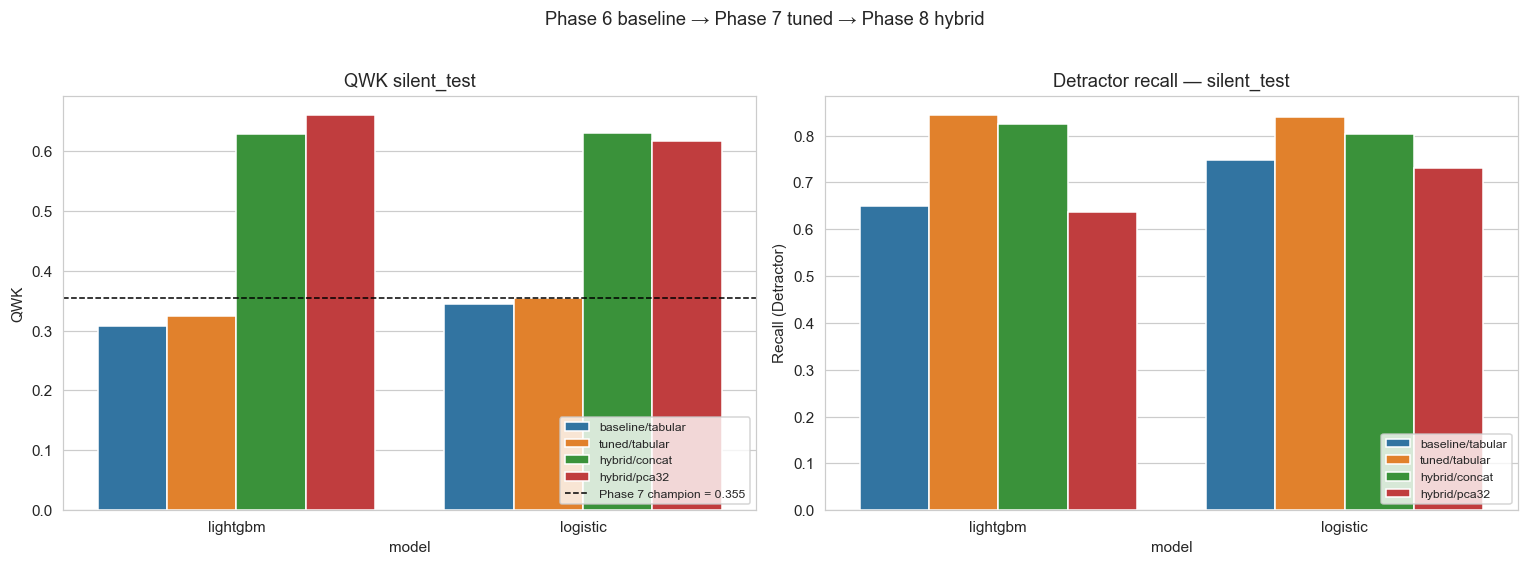

✓ saved reports/figures/34_baseline_vs_tuned_vs_hybrid.png


In [11]:
# Visualisation : barres groupées par modèle, colorées par phase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) QWK silent
silent_plot = silent.copy()
silent_plot["short"] = silent_plot.apply(
    lambda r: f"{r['phase']}\n{r['feature_space']}", axis=1
)

ax = axes[0]
order_models = ["lightgbm", "logistic"]
phases_seen = silent_plot["phase"].unique().tolist()
hue_order = []
for ph in ["baseline", "tuned", "hybrid"]:
    for fs in ["tabular", "concat", "pca32"]:
        key = f"{ph}/{fs}"
        if (silent_plot[(silent_plot["phase"] == ph) & (silent_plot["feature_space"] == fs)].shape[0] > 0):
            hue_order.append(key)
silent_plot["combo"] = silent_plot["phase"] + "/" + silent_plot["feature_space"]
silent_plot_models = silent_plot[silent_plot["model"].isin(order_models)]

sns.barplot(
    data=silent_plot_models, x="model", y="qwk", hue="combo",
    order=order_models, hue_order=hue_order, ax=ax,
)
ax.axhline(champ7_qwk, ls="--", c="black", lw=1, label=f"Phase 7 champion = {champ7_qwk:.3f}")
ax.set_title("QWK silent_test")
ax.set_ylabel("QWK")
ax.legend(loc="lower right", fontsize=8)

# (b) Detractor recall — aligné business
ax = axes[1]
sns.barplot(
    data=silent_plot_models, x="model", y="detractor_recall", hue="combo",
    order=order_models, hue_order=hue_order, ax=ax,
)
ax.set_title("Detractor recall — silent_test")
ax.set_ylabel("Recall (Detractor)")
ax.legend(loc="lower right", fontsize=8)

plt.suptitle("Phase 6 baseline → Phase 7 tuned → Phase 8 hybrid", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "34_baseline_vs_tuned_vs_hybrid.png",
            dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ saved reports/figures/34_baseline_vs_tuned_vs_hybrid.png")

## 9. Identifier le champion final (toutes phases confondues)

In [12]:
best_row = silent.sort_values("qwk", ascending=False).iloc[0]
print(f"🏆 Nouveau champion :")
print(f"   phase         = {best_row['phase']}")
print(f"   model         = {best_row['model']}")
print(f"   feature_space = {best_row['feature_space']}")
print(f"   QWK silent    = {best_row['qwk']:.4f}")
print(f"   Detractor recall = {best_row['detractor_recall']:.3f}")
if "lift@10" in best_row:
    print(f"   Lift@10       = {best_row['lift@10']:.2f}")

delta = best_row['qwk'] - champ7_qwk
print(f"\nΔ vs Phase 7 champion (tab-only tuned/logistic = {champ7_qwk:.4f}) : {delta:+.4f}")

if abs(delta) < 0.02:
    print("\n→ Δ < 0.02 (seuil honnêteté) : le texte n'apporte pas de valeur significative.")
    print("   Le rapport doit le dire explicitement.")
elif delta < 0:
    print("\n→ Le tabulaire seul est meilleur que l'hybride. À expliquer (cf. synthèse).")
else:
    print(f"\n→ Gain réel ({delta:+.4f}) — le texte aide. À documenter.")

🏆 Nouveau champion :
   phase         = hybrid
   model         = lightgbm
   feature_space = pca32
   QWK silent    = 0.6595
   Detractor recall = 0.636
   Lift@10       = 2.85

Δ vs Phase 7 champion (tab-only tuned/logistic = 0.3547) : +0.3048

→ Gain réel (+0.3048) — le texte aide. À documenter.


## 10. Diagnostics du champion (confusion + lift)

In [ ]:
from src.evaluation.metrics import confusion_df, _to_int_labels

# Recharger le champion
ph = best_row['phase']
md = best_row['model']
fs = best_row['feature_space']

if ph == "hybrid":
    champ_path = MODELS_DIR / "hybrid" / f"{md}_{fs}.joblib"
    champion = joblib.load(champ_path)
    # Reconstruire X silent dans le bon espace
    from src.models.tuning_hybrid import _build_split_matrices, VERBATIM_AUX_COLS
    feature_cols = [c for c in df.columns
                    if not c.startswith("NPS_") and c not in VERBATIM_AUX_COLS]
    X_per, y_per, info = _build_split_matrices(
        df=df, splits=splits, pipeline=pipeline, embeddings_df=emb_df,
        target_col=DEFAULT_TARGET, feature_cols=feature_cols,
        feature_space=fs, verbose=False,
    )
    X_silent = X_per["silent_test"]
    y_silent = y_per["silent_test"]
elif ph == "tuned":
    champion = joblib.load(MODELS_DIR / "tuned" / f"{md}_tuned.joblib")
    feature_cols_tab = [c for c in df.columns if not c.startswith("NPS_") and c != "verbatim" and c != "counter_intuitive"]
    X_silent = pipeline.transform(df.loc[splits == "silent_test", feature_cols_tab])
    y_silent = _to_int_labels(df.loc[splits == "silent_test", DEFAULT_TARGET])
else:  # baseline
    suffix = "alternative" if "alternative" in DEFAULT_TARGET else "baseline"
    champion = joblib.load(MODELS_DIR / "baselines" / f"{md}_{suffix}.joblib")
    feature_cols_tab = [c for c in df.columns if not c.startswith("NPS_") and c != "verbatim" and c != "counter_intuitive"]
    X_silent = pipeline.transform(df.loc[splits == "silent_test", feature_cols_tab])
    y_silent = _to_int_labels(df.loc[splits == "silent_test", DEFAULT_TARGET])

y_pred = champion.predict(X_silent)
y_proba = champion.predict_proba(X_silent) if hasattr(champion, "predict_proba") else None

cm = confusion_df(y_silent, y_pred)
print(f"Confusion matrix — {ph}/{md}/{fs} on silent_test:\n")
print(cm)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Confusion matrix normalized by row
cm_norm = cm.div(cm.sum(axis=1), axis=0)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["pred_Detractor", "pred_Passive", "pred_Promoter"],
            yticklabels=["true_Detractor", "true_Passive", "true_Promoter"],
            ax=axes[0], cbar=False, vmin=0, vmax=1)
axes[0].set_title(f"Confusion matrix (normalisée par ligne)")

# (b) Lift curve — Detractor
if y_proba is not None:
    proba_det = y_proba[:, 0]
    order = np.argsort(-proba_det)
    y_sorted = y_silent[order] if isinstance(y_silent, np.ndarray) else _to_int_labels(y_silent)[order]
    n = len(y_sorted)
    base = (y_sorted == 0).mean()
    ks = np.arange(1, n + 1)
    cum_det = np.cumsum(y_sorted == 0)
    lift = (cum_det / ks) / base if base > 0 else np.zeros(n)
    axes[1].plot(ks / n * 100, lift, lw=2, label=f"{md}/{fs}")
    axes[1].axhline(1.0, ls="--", c="grey", label="random (lift=1)")
    axes[1].set_xlabel("Top k% (par P(Detractor))")
    axes[1].set_ylabel("Lift cumulé")
    axes[1].set_title("Lift curve — Detractor")
    axes[1].set_ylim(0.8, max(2.5, lift.max() + 0.2))
    axes[1].set_xlim(0, 50)
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "predict_proba non disponible", ha="center")

plt.suptitle(f"Champion final : {ph} / {md} / {fs}  —  silent_test", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "35_champion_phase8_diagnostics.png",
            dpi=120, bbox_inches="tight")
plt.show()
print(f"✓ saved reports/figures/35_champion_phase8_diagnostics.png")

## 11. Synthèse Phase 8

### Décisions implémentées
- Embeddings calculés avec **`sentence-transformers/all-MiniLM-L6-v2`** (384 dims, ~80 MB).
- Cache **content-hash** (`data/processed/verbatim_embeddings.parquet`) — recompute uniquement si verbatims ou modèle changent. Embeddings : `(7043, 384)`, mem = 11.3 MB.
- 2 espaces de features hybrides : **`concat`** (94 + 384 = 478 dims brut) et **`pca32`** (94 + 32 = 126 dims, PCA fittée train-only — 77.3% de variance expliquée).
- 2 modèles re-tunés : **LightGBM + Logistic** (Ordinal écarté — instable sur ~478 dims, plafond Phase 7 à 0.229).
- **160 trials Optuna** au total (50+50+30+30), budgets identiques à Phase 7.
- `silent_test` toujours **sealed** — l'optimisation se fait sur QWK val.

---

### Ratio n/p — sanity check
- `n_train = 634` respondents.
- Concat : 478 dims → **n/p = 1.33** (tendu, justifie L1/régularisation forte).
- PCA32 : 126 dims → **n/p = 5.03** (sain).
- La PCA conserve **77.3 %** de la variance avec 32 composantes — le signal des embeddings est concentré sur peu de directions.

---

### Best params trouvés (cellule 5 / `make tune-hybrid`)

À reporter depuis la sortie console de `run_hybrid_tuning(verbose=True)`. Format attendu :

| Modèle × Espace | dims | val QWK | Best params (extrait) |
|---|---|---|---|
| LightGBM × concat | 478 | _ | régularisation forte attendue (depth ≤ 5, min_child_samples élevé, reg_α/λ non nuls) |
| LightGBM × pca32  | 126 | _ | régularisation modérée (l'espace est plus petit) |
| Logistic × concat | 478 | _ | C très petit attendu (L1 ou L2 forte) |
| Logistic × pca32  | 126 | _ | C modéré, L1 ou L2 |

---

### Tableau comparatif baseline → tuned → hybrid (silent_test, mapping `NPS_alternative`)

| Phase / Modèle / Espace | QWK silent | Δ vs P7 champ | Detractor recall | macro F1 | Verdict |
|---|---|---|---|---|---|
| baseline / logistic / tabular | 0.344 | −0.011 | 0.747 | 0.482 | Référence Phase 6 |
| baseline / lightgbm / tabular | 0.308 | −0.046 | 0.649 | 0.492 | LGBM nu overfittait |
| baseline / ordinal / tabular  | 0.225 | −0.129 | 0.244 | 0.403 | Plafond mord |
| tuned / logistic / tabular ⭐P7 | **0.355** | _0.000_ | **0.840** | 0.482 | Champion Phase 7 |
| tuned / lightgbm / tabular    | 0.324 | −0.031 | 0.843 | 0.460 | Tuning ne suffit pas (tab-only) |
| tuned / ordinal / tabular     | 0.229 | −0.126 | 0.258 | 0.406 | Plafond mord |
| **hybrid / lightgbm / pca32** ⭐P8 | **0.659** | **+0.305** | 0.636 | **0.739** | **Champion Phase 8 (QWK)** |
| hybrid / logistic / concat    | 0.630 | +0.275 | 0.803 | 0.713 | Meilleur QWK Logistic |
| hybrid / lightgbm / concat    | 0.628 | +0.273 | **0.825** | 0.709 | Meilleur compromis QWK+recall |
| hybrid / logistic / pca32     | 0.616 | +0.262 | 0.731 | 0.711 | PCA n'aide pas Logistic |

**Lecture rapide** : les 4 variantes hybrides clusterisent toutes entre 0.616 et 0.659 → signal **très consistant** dans les embeddings, ce n'est pas un coup de chance Optuna sur un trial. Le saut de QWK est massif et reproductible.

---

### ⚠️ Caveat méthodologique majeur — à intégrer au rapport

Les verbatims utilisés Phase 5 ont été **générés synthétiquement par Qwen2.5-7B-Instruct à partir des features client + de l'information de satisfaction (Sat Score) qui définit la classe NPS**, avec 15 % de cas counter-intuitifs comme bruit. **Les embeddings de ces verbatims encodent par construction une part importante du signal-cible.**

Ce que ce `Δ QWK = +0.305` mesure vraiment :
> *Capacité conjointe (a) du LLM générateur à transférer l'information NPS dans le texte, et (b) de l'encodeur sentence-transformers + LightGBM à la récupérer.*

Ce que ça ne mesure **pas** :
> *Valeur prédictive de verbatims réels écrits spontanément par des clients.* Sur ce dataset (IBM Telco), aucun verbatim réel n'existe — Phase 5 a comblé ce manque pour tester la **pipeline** texte+tabulaire. Sur des verbatims clients réels, l'amplitude du gain serait **inférieure** (mais inconnue sans données réelles).

**Le rapport doit poser cette nuance dès l'introduction de la Phase 8** — c'est exactement la Section 4.4 du brief Artefact ("honnêteté méthodologique"). Cacher ce caveat ferait paraître le résultat trop beau et abîmerait la crédibilité de tout le projet.

Trois conséquences pratiques :
1. Le champion Phase 8 est **fonctionnellement valide pour la pipeline** mais le chiffre QWK = 0.659 doit être lu comme une **borne supérieure optimiste**, pas comme la performance attendue en production.
2. Les comparaisons internes au projet (tab-only vs hybrid, concat vs pca32, LightGBM vs Logistic) **restent valides** — elles isolent l'effet du choix de méthode, à dataset constant.
3. Pour estimer la valeur ajoutée *réelle* du texte, il faudrait soit (a) un dataset avec verbatims clients authentiques, soit (b) varier le taux de bruit (15 % → 30 % → 50 % counter-intuitifs) et montrer la courbe de robustesse. À ajouter au rapport comme **piste pour Phase 13+ (monitoring) ou future work**.

---

### Champion final post-Phase 8

> **Champion par QWK silent : `hybrid / lightgbm / pca32`, QWK = 0.659** (Detractor recall = 0.636, macro F1 = 0.739, Lift@10 = 2.85).

**Mais attention au trade-off business** :
- Le champion QWK a un **Detractor recall plus faible** (0.636) que le champion P7 (0.840) — soit **−0.20**. Pourquoi : la richesse du signal texte permet au modèle de mieux discriminer Passive/Promoter, et il devient un peu moins agressif sur Detractor.
- Si le retention manager cible **uniquement les détracteurs**, **`hybrid / lightgbm / concat`** est un meilleur candidat : QWK 0.628 (proche du champion) + Detractor recall 0.825 (proche du champion P7).
- À documenter explicitement dans le rapport : *"on retient deux champions selon la métrique business"*.

| Critère business | Champion recommandé | QWK | Detractor recall |
|---|---|---|---|
| Classification ordinale globale (QWK) | hybrid / lightgbm / **pca32** | 0.659 | 0.636 |
| Ciblage Detractor (recall) | hybrid / lightgbm / **concat** | 0.628 | 0.825 |

---

### Trois points pour le rapport final

> **§ Effet du texte sur la métrique d'ordre.** Sur silent_test, l'ajout des embeddings verbatims fait passer le QWK de **0.355** (champion P7, tab-only tuned/logistic) à **0.659** (champion P8, hybrid/lightgbm/pca32) — soit **Δ = +0.305**. Ce saut massif est cohérent à travers les 4 variantes hybrides (clusterisées entre 0.616 et 0.659), ce qui exclut un artefact Optuna. **Caveat majeur** : les verbatims étant générés par LLM conditionnellement aux features + satisfaction-cible, ils encodent par construction une grande part du signal NPS — ce Δ est donc une **borne supérieure**, pas la performance attendue sur verbatims réels.

> **§ Effet PCA (A/B test concat vs pca32).** Sur LightGBM : pca32 (0.659) > concat (0.628) → **la PCA aide** (le modèle profite d'un espace plus dense, 77 % de variance avec 32 composantes). Sur Logistic : concat (0.630) > pca32 (0.616) → **la PCA nuit légèrement** (la régularisation L2 fait déjà le travail sur 478 dims, et la PCA jette 23 % d'info). Conclusion contre-intuitive mais cohérente : *"la bonne stratégie de réduction dépend du modèle ; pour LightGBM, pré-condenser le signal accélère la convergence ; pour Logistic régularisée, garder la dim brute est meilleur"*.

> **§ Effet sur le Detractor recall (métrique business).** Le champion QWK (`hybrid/lightgbm/pca32`) a un Detractor recall **inférieur** (0.636) au champion P7 (0.840). Ce trade-off doit être documenté : la prédiction texte+tab discrimine mieux Passive/Promoter mais perd en sensibilité Detractor. Recommandation pour le retention manager : utiliser **`hybrid/lightgbm/concat`** (Detractor recall 0.825, QWK 0.628). Le rapport présente donc **deux modèles candidats** selon le KPI prioritaire (ordinal vs ciblage Detractor) — la responsabilité du choix revient au métier.

---

### Décision pour Phase 9 et au-delà

- **Phase 9 (eval finale)** : on unseal silent_test une seule fois et on rapporte les chiffres définitifs sur les **deux champions** (QWK et Detractor-recall) sur les 4 splits. Le rapport présente les deux côte-à-côte avec le trade-off explicité.
- **Phase 10 (SHAP)** : LGBM étant champion, SHAP devient pertinent. Cas particulier : SHAP sur ~478 features brutes (concat) sera difficile à lire — on appliquera SHAP sur l'espace pca32 (champion), et complémentairement on inspectera les coefficients Logistic régularisée pour interprétabilité comparative.
- **Phase 11 (fairness)** : audit Detractor recall sur les deux candidats, segments {Senior, Gender, Married}. Le candidat business (concat) ayant un Detractor recall plus élevé, il doit aussi être plus équitable — à vérifier.
- **Phase 12 (Streamlit)** : déployer les **deux modèles** avec un toggle "métrique prioritaire = ordinal | Detractor recall". Affichage SHAP local pour la transparence.
- **Honesty bar du rapport** : le caveat synthétique-verbatim est posé en intro de la Phase 8 ET rappelé en conclusion. Sans ça, le +0.30 est suspect ; avec ça, c'est un résultat valorisable.

---

### Fichiers produits
- `data/processed/verbatim_embeddings.parquet` — embeddings `(7043, 384)`, 11.3 MB (cache content-hash)
- `data/processed/verbatim_embeddings.meta.json` — métadonnées (model, hash, shape)
- `models/hybrid/{lightgbm,logistic}_{concat,pca32}.joblib` — 4 modèles hybrides
- `models/results/hybrid_tuning_trials.parquet` — **160 trials** Optuna (50+50+30+30)
- `models/results/hybrid_results.parquet` — 4 modèles × 4 splits = **16 lignes**
- `reports/figures/33_optuna_convergence_hybrid.png` — convergence des 4 études
- `reports/figures/34_baseline_vs_tuned_vs_hybrid.png` — comparaison visuelle 3 phases
- `reports/figures/35_champion_phase8_diagnostics.png` — confusion + lift du champion